# 📓 Notebook 02: Indexação no Vector Store (ChromaDB) e Auditoria do RAG Agêntico

**Projeto:** Ideias em Rede — RAG Agêntico & Auditoria Documental (`PublicHearingBR`)
**Subpasso:** 2.2 — Fatiamento Completo, Auditoria de Oradores, Indexação em Lote (`BAAI/bge-m3`) e Testes de Busca Semântica.

---

## 1. Setup & Importação de Módulos

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Adiciona o diretório raiz ao path para importação dos módulos de src
sys.path.append("..")

from src.loader import load_lds_data, load_nli_data
from src.chunking import (
    chunk_transcriptions_by_speaker,
    chunk_news_articles,
    chunk_nli_records
)
from src.embeddings import get_embedding_model
from src.vector_store import get_chroma_client, index_documents_in_collection

# Configuração visual do Matplotlib/Seaborn
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 120
print("✅ Setup e importações concluídos com sucesso!")

✅ Setup e importações concluídos com sucesso!


## 2. Carregamento e Chunking Completo das Bases LDS e NLI

In [2]:
print("⏳ Carregando dataset PublicHearingBR completo (LDS e NLI)..." )
df_lds = load_lds_data()
df_nli = load_nli_data(flatten=True)

print(f"📊 Registros LDS carregados: {len(df_lds):,}")
print(f"📊 Registros NLI carregados (desaninhados): {len(df_nli):,}")

print("\n⏳ Executando fatiamento híbrido dos documentos...")
docs_transcricao = chunk_transcriptions_by_speaker(df_lds, max_tokens=800, overlap=150)
docs_noticia = chunk_news_articles(df_lds, chunk_size=1000, overlap=150)
docs_nli = chunk_nli_records(df_nli)

summary_df = pd.DataFrame([
    {"Coleção": "transcricoes_db", "Tipo de Documento": "Transcrição (por Orador)", "Total Chunks": len(docs_transcricao)},
    {"Coleção": "noticias_db", "Tipo de Documento": "Matéria Jornalística", "Total Chunks": len(docs_noticia)},
    {"Coleção": "nli_metadados_db", "Tipo de Documento": "Opinião / Anotação NLI", "Total Chunks": len(docs_nli)},
])
display(summary_df)

⏳ Carregando dataset PublicHearingBR completo (LDS e NLI)...
📊 Registros LDS carregados: 206
📊 Registros NLI carregados (desaninhados): 4,238

⏳ Executando fatiamento híbrido dos documentos...


,Coleção,Tipo de Documento,Total Chunks
0,transcricoes_db,Transcrição (por Orador),21925
1,noticias_db,Matéria Jornalística,1073
2,nli_metadados_db,Opinião / Anotação NLI,4238


## 3. Auditoria de Qualidade da Regex de Oradores e Distribuição de Chunks

In [3]:
# Extração dos metadados dos chunks de transcrição
speaker_metadata_list = [doc.metadata for doc in docs_transcricao]
df_speakers = pd.DataFrame(speaker_metadata_list)

top_speakers = df_speakers["orador"].value_counts().head(15).reset_index()
top_speakers.columns = ["Orador / Cargo Identificado", "Frequência de Chunks"]

print("📋 Top 15 Oradores/Deputados Mais Frequentes Identificados pela Regex:")
display(top_speakers)

📋 Top 15 Oradores/Deputados Mais Frequentes Identificados pela Regex:


,Orador / Cargo Identificado,Frequência de Chunks
0,O SR. PRESIDENTE(Aureo Ribeiro. Bloco/SOLIDARI...,692
1,O SR. ALFREDO GASPAR(Bloco/UNIÃO - AL),640
2,A SRA. PRESIDENTE(Bia Kicis. PL - DF),576
3,O SR. CAIO VIANNA(Bloco/PSD - RJ),544
4,O SR. AUGUSTO JULIO SOARES MADUREIRA,488
5,O SR. RICARDO SILVA(Bloco/PSD - SP),442
6,O SR. RAMIRO JULIO SOARES MADUREIRA,426
7,O SR. MAX GAUDERETO OLIVEIRA,324
8,A SRA. TANIA SILVA SANTOS MADUREIRA,310
9,O SR. MINISTRO PAULO TEIXEIRA,242


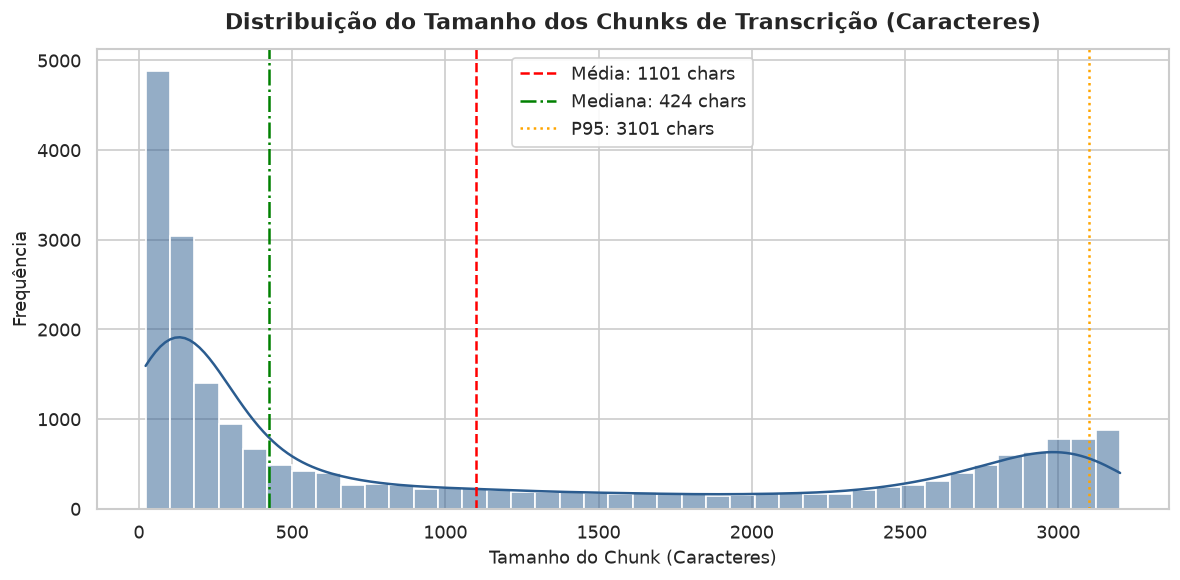

📐 Métricas Estatísticas: Média=1100.8 chars | Mediana=424.0 chars | P95=3101.0 chars


In [4]:
# Distribuição do tamanho dos chunks de transcrição (em caracteres)
chunk_lengths = [len(doc.page_content) for doc in docs_transcricao]
df_lengths = pd.DataFrame({"char_length": chunk_lengths})

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_lengths["char_length"], bins=40, kde=True, color="#2b5c8f", ax=ax)
ax.set_title("Distribuição do Tamanho dos Chunks de Transcrição (Caracteres)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Tamanho do Chunk (Caracteres)", fontsize=11)
ax.set_ylabel("Frequência", fontsize=11)

mean_len = df_lengths["char_length"].mean()
median_len = df_lengths["char_length"].median()
p95_len = df_lengths["char_length"].quantile(0.95)

ax.axvline(mean_len, color="red", linestyle="--", label=f"Média: {mean_len:.0f} chars")
ax.axvline(median_len, color="green", linestyle="-.", label=f"Mediana: {median_len:.0f} chars")
ax.axvline(p95_len, color="orange", linestyle=":", label=f"P95: {p95_len:.0f} chars")
ax.legend(frameon=True, facecolor="white", framealpha=0.9)
plt.tight_layout()
plt.show()

print(f"📐 Métricas Estatísticas: Média={mean_len:.1f} chars | Mediana={median_len:.1f} chars | P95={p95_len:.1f} chars")

## 4. Vetorização & Persistência no ChromaDB (`BAAI/bge-m3`)

In [5]:
print("⏳ Inicializando modelo de embeddings BAAI/bge-m3...")
embedding_model = get_embedding_model("BAAI/bge-m3", device="cpu")

print("\n⏳ Conectando ao cliente persistente do ChromaDB em 'data/processed/chroma_db'...")
chroma_client = get_chroma_client("data/processed/chroma_db")

print("\n⏳ Indexando coleção: transcricoes_db...")
vs_transcricoes = index_documents_in_collection(
    client=chroma_client,
    collection_name="transcricoes_db",
    documents=docs_transcricao,
    embedding_model=embedding_model,
    batch_size=100
)

print("\n⏳ Indexando coleção: noticias_db...")
vs_noticias = index_documents_in_collection(
    client=chroma_client,
    collection_name="noticias_db",
    documents=docs_noticia,
    embedding_model=embedding_model,
    batch_size=100
)

print("\n⏳ Indexando coleção: nli_metadados_db...")
vs_nli = index_documents_in_collection(
    client=chroma_client,
    collection_name="nli_metadados_db",
    documents=docs_nli,
    embedding_model=embedding_model,
    batch_size=100
)

db_summary = pd.DataFrame([
    {"Coleção": "transcricoes_db", "Documentos Vetorizados": vs_transcricoes._collection.count()},
    {"Coleção": "noticias_db", "Documentos Vetorizados": vs_noticias._collection.count()},
    {"Coleção": "nli_metadados_db", "Documentos Vetorizados": vs_nli._collection.count()},
])
print("\n✅ Resumo da Persistência no ChromaDB:")
display(db_summary)

⏳ Inicializando modelo de embeddings BAAI/bge-m3...


/home/rpcosta/Códigos/knownledge Lab/notebooks/../src/embeddings.py:66: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]


⏳ Conectando ao cliente persistente do ChromaDB em 'data/processed/chroma_db'...

⏳ Indexando coleção: transcricoes_db...
[vector_store] Coleção 'transcricoes_db' já contém 21925 documentos. Reutilizando dados persitidos.

⏳ Indexando coleção: noticias_db...
[vector_store] Coleção 'noticias_db' já contém 1073 documentos. Reutilizando dados persitidos.

⏳ Indexando coleção: nli_metadados_db...
[vector_store] Coleção 'nli_metadados_db' já contém 4238 documentos. Reutilizando dados persitidos.

✅ Resumo da Persistência no ChromaDB:


/home/rpcosta/Códigos/knownledge Lab/notebooks/../src/vector_store.py:85: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vector_store = Chroma(


,Coleção,Documentos Vetorizados
0,transcricoes_db,21925
1,noticias_db,1073
2,nli_metadados_db,4238


## 5. Testes de Sanidade de Busca Semântica (Retrieval Sanity Test)

In [6]:
# Helper para renderizar resultados de busca semântica em Markdown
def display_search_results(query: str, results: list, collection_name: str):
    md_output = f"### 🔎 Busca na Coleção: `{collection_name}`\n"
    md_output += f"**Query:** *\"{query}\"*\n\n"
    for i, (doc, score) in enumerate(results, 1):
        md_output += f"#### Result {i} (Distância/Score: `{score:.4f}`)\n"
        md_output += f"**Metadados:** `{doc.metadata}`\n\n"
        snippet = doc.page_content[:350].replace("\n", " ")
        md_output += f"> {snippet}...\n\n"
        md_output += "---\n"
    display(Markdown(md_output))

In [7]:
print("🔹 TESTE 1: Busca Semântica em 'transcricoes_db' com filtro de metadados")
query_1 = "censura e liberdade de expressão nas redes sociais"
sample_speaker = docs_transcricao[0].metadata.get("orador")
results_1 = vs_transcricoes.similarity_search_with_score(
    query=query_1,
    k=3,
    filter={"orador": sample_speaker}
)
display_search_results(f"{query_1} (Filtro Orador: {sample_speaker})", results_1, "transcricoes_db")

🔹 TESTE 1: Busca Semântica em 'transcricoes_db' com filtro de metadados


### 🔎 Busca na Coleção: `transcricoes_db`
**Query:** *"censura e liberdade de expressão nas redes sociais (Filtro Orador: O SR. PRESIDENTE(Lucas Redecker. Bloco/PSDB - RS))"*

#### Result 1 (Distância/Score: `0.9458`)
**Metadados:** `{'doc_id': 1, 'assunto': 'Acusações de censura contra Alexandre de Moraes por exigir bloqueio de contas na rede social X', 'tipo': 'transcricao', 'orador': 'O SR. PRESIDENTE(Lucas Redecker. Bloco/PSDB - RS)'}`

> O SR. PRESIDENTE(Lucas Redecker. Bloco/PSDB - RS) - Muito boa tarde.  Em nome da Comissão de Relações Exteriores e de Defesa Nacional, dou as boas-vindas aos nossos convidados, que pronta e gentilmente aceitaram o convite para participar deste importante debate.  Cumprimento de forma especial todas as Deputadas e Deputados que participam desta reun...

---
#### Result 2 (Distância/Score: `0.9794`)
**Metadados:** `{'assunto': 'Acusações de censura contra Alexandre de Moraes por exigir bloqueio de contas na rede social X', 'doc_id': 1, 'tipo': 'transcricao', 'orador': 'O SR. PRESIDENTE(Lucas Redecker. Bloco/PSDB - RS)'}`

> O SR. PRESIDENTE(Lucas Redecker. Bloco/PSDB - RS) - Muito obrigado, Deputado Marcel van Hattem, a quem parabenizo.  Quero, mais uma vez, aqui, como autor do projeto, dizer que esse é um tema importantíssimo a ser debatido dentro desta Comissão, que trouxe a possibilidade do amplo debate a todos os Parlamentares que estiveram inscritos. Contudo, ent...

---
#### Result 3 (Distância/Score: `1.1319`)
**Metadados:** `{'assunto': 'Acusações de censura contra Alexandre de Moraes por exigir bloqueio de contas na rede social X', 'tipo': 'transcricao', 'orador': 'O SR. PRESIDENTE(Lucas Redecker. Bloco/PSDB - RS)', 'doc_id': 1}`

> O SR. PRESIDENTE(Lucas Redecker. Bloco/PSDB - RS) - Muito obrigado, Sr. Michael Shellenberger, pelas suas considerações finais  Também quero agradecer a todos os convidados desta audiência pública pela disponibilidade, bem como ao autor do requerimento desta audiência pública, Deputado Marcel van Hattem, a quem passo a palavra para as suas consider...

---


In [8]:
print("🔹 TESTE 2: Busca Semântica em 'noticias_db' (Agência Câmara)")
query_2 = "regulamentação de plataformas digitais e projeto de lei das fake news"
results_2 = vs_noticias.similarity_search_with_score(
    query=query_2,
    k=3
)
display_search_results(query_2, results_2, "noticias_db")

🔹 TESTE 2: Busca Semântica em 'noticias_db' (Agência Câmara)


### 🔎 Busca na Coleção: `noticias_db`
**Query:** *"regulamentação de plataformas digitais e projeto de lei das fake news"*

#### Result 1 (Distância/Score: `0.6716`)
**Metadados:** `{'assunto': 'Regulamentação dos mercados digitais no Brasil', 'tipo': 'noticia', 'doc_id': 195}`

> Suavizar o controle Uma regulação focada na suavização do controle de acesso essencial das plataformas digitais foi defendida pelo professor de direito da concorrência da Universidade de Direito Tilburg, dos Países Baixos, Giorgio Monti. Ele destacou que a regulação, diferentemente do que muitos imaginam, não trata de combate às notícias falsas que...

---
#### Result 2 (Distância/Score: `0.7804`)
**Metadados:** `{'tipo': 'noticia', 'doc_id': 195, 'assunto': 'Regulamentação dos mercados digitais no Brasil'}`

> Ao regulamentar os mercados digitais, o projeto, do deputado João Maia (PL-RN), visa proteger a concorrência empresarial e os consumidores para que não se tornem reféns de empresas que dominam setores da prestação de serviços, as chamadas big techs - grandes empresas de tecnologia, como Google, Meta, Amazon e Apple, que valem juntas mais do que as ...

---
#### Result 3 (Distância/Score: `0.7857`)
**Metadados:** `{'doc_id': 1, 'assunto': 'Acusações de censura contra Alexandre de Moraes por exigir bloqueio de contas na rede social X', 'tipo': 'noticia'}`

> David Ágape criticou ainda o Projeto de Lei 2630/20, conhecido como PL das Fake News, e defendeu o Marco Civil da Internet. Recentemente o presidente da Câmara dos Deputados, Arthur Lira (PP-AL), afirmou que a proposta não vai ser votada na forma atual, mas que vai criar um grupo de trabalho para debater o texto.      Reportagem - Lara Haje Edição ...

---


In [9]:
print("🔹 TESTE 3: Busca Semântica em 'nli_metadados_db' (Rótulos de Alucinação)")
query_3 = "acusou alexandre de moraes de agir sem base legal"
results_3 = vs_nli.similarity_search_with_score(
    query=query_3,
    k=3
)
display_search_results(query_3, results_3, "nli_metadados_db")

🔹 TESTE 3: Busca Semântica em 'nli_metadados_db' (Rótulos de Alucinação)


### 🔎 Busca na Coleção: `nli_metadados_db`
**Query:** *"acusou alexandre de moraes de agir sem base legal"*

#### Result 1 (Distância/Score: `1.0354`)
**Metadados:** `{'doc_id': 1, 'envolvido_nome': 'Glenn Greenwald', 'tipo': 'nli_opinion', 'verificacao_manual': False, 'cargo': 'Jornalista'}`

> Opinião (Glenn Greenwald - Jornalista): Denunciou que as ordens de censura do STF são completamente secretas, sem acusação específica e sem oportunidade de defesa.  Contexto (Chunks Próximos): Para entender isso, eu gostaria de usar uma ordem de censura emitida pelo Ministro Alexandre de Moraes, que ele mandou ficar sob sigilo, em segredo, para nin...

---
#### Result 2 (Distância/Score: `1.0570`)
**Metadados:** `{'cargo': 'Desembargador aposentado do Tribunal de Justiça do Distrito Federal', 'doc_id': 17, 'envolvido_nome': 'Sebastião Coelho', 'verificacao_manual': False, 'tipo': 'nli_opinion'}`

> Opinião (Sebastião Coelho - Desembargador aposentado do Tribunal de Justiça do Distrito Federal): Argumentou que a intromissão do STF nas competências dos outros Poderes é indevida e viola a legitimidade democrática.  Contexto (Chunks Próximos): Senhores e senhoras, nós não estamos vivendo uma normalidade, estamos vivendo o ápice da crise política,...

---
#### Result 3 (Distância/Score: `1.0586`)
**Metadados:** `{'verificacao_manual': True, 'doc_id': 17, 'cargo': 'Desembargador aposentado do Tribunal de Justiça do Distrito Federal', 'tipo': 'nli_opinion', 'envolvido_nome': 'Sebastião Coelho'}`

> Opinião (Sebastião Coelho - Desembargador aposentado do Tribunal de Justiça do Distrito Federal): Criticou a relação de proximidade entre Ministros do STF e parlamentares, alegando que isso compromete a independência dos Poderes.  Contexto (Chunks Próximos): Senhores e senhoras, nós não estamos vivendo uma normalidade, estamos vivendo o ápice da cr...

---
